In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV file
df_fisico_quimicas = pd.read_csv('/content/fisico-quimicas.csv')

# Display the first 5 rows of the DataFrame
print('Primeiras 5 linhas do DataFrame:')
display(df_fisico_quimicas.head())

# Display information about the DataFrame to see column names and types
print('\nInformações do DataFrame:')
df_fisico_quimicas.info()

Primeiras 5 linhas do DataFrame:


,Amostra,Categoria,Solidos_Soluveis_Brix,Acucar_g_100g,pH,Acidez_g_100mL,Acucar_estimado
0,A27,Frutas,14.12,9.42,2.86,0.65,8.706996
1,A05,Sucos e bebidas,10.02,7.17,2.83,0.79,5.552567
2,A60,Néctares e polpas,13.41,5.10,3.03,0.88,8.160741
3,A41,Néctares e polpas,23.37,15.14,2.90,0.45,15.823696
4,A10,Sucos e bebidas,7.71,5.05,2.99,0.79,3.775315



Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Amostra                60 non-null     object 
 1   Categoria              60 non-null     object 
 2   Solidos_Soluveis_Brix  60 non-null     float64
 3   Acucar_g_100g          60 non-null     float64
 4   pH                     60 non-null     float64
 5   Acidez_g_100mL         60 non-null     float64
 6   Acucar_estimado        60 non-null     float64
dtypes: float64(5), object(2)
memory usage: 3.4+ KB


Para analisar a relação entre os valores de açúcar estimado e medido, precisamos identificar as colunas correspondentes no DataFrame. Assumindo que as colunas sejam `Estimado` e `Medido` (ou nomes similares em português, como `Açúcar Estimado` e `Açúcar Medido`), podemos criar um gráfico de dispersão. Caso os nomes das colunas sejam diferentes, por favor, me informe.

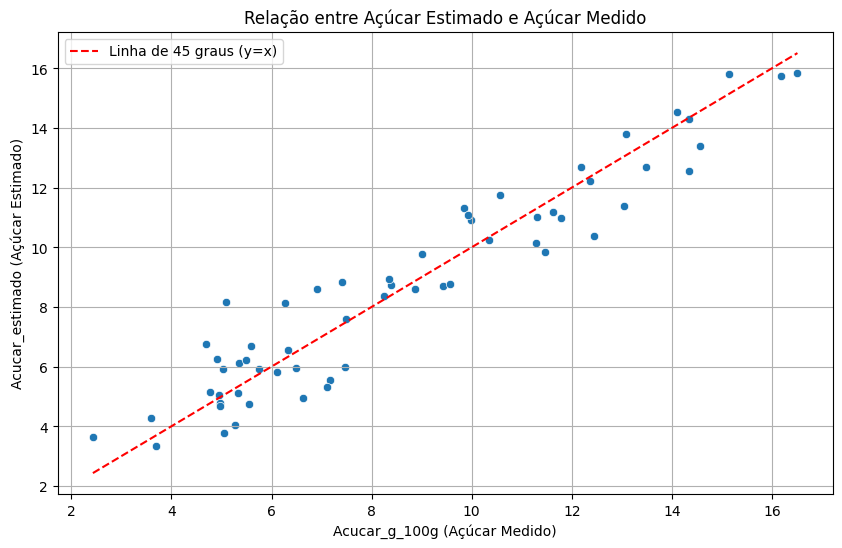


Coeficiente de Correlação de Pearson entre Acucar_g_100g e Acucar_estimado: 0.9522


In [ ]:
# Tentativa de plotar com nomes de colunas comuns. Por favor, ajuste se os nomes forem diferentes.
# Substitua 'nome_da_coluna_acucar_estimado' e 'nome_da_coluna_acucar_medido' pelos nomes corretos das colunas no seu CSV.
# Por exemplo, se as colunas forem 'Estimado' e 'Medido', use-as diretamente.

# Verifique se as colunas 'Acucar_g_100g' e 'Acucar_estimado' existem no DataFrame
if 'Acucar_g_100g' in df_fisico_quimicas.columns and 'Acucar_estimado' in df_fisico_quimicas.columns:
    coluna_medido = 'Acucar_g_100g'
    coluna_estimado = 'Acucar_estimado'
else:
    print("Não foi possível encontrar as colunas 'Acucar_g_100g' e 'Acucar_estimado'. Por favor, verifique os nomes das colunas e atualize o código.")
    # Display all columns to help the user identify them
    print("Colunas disponíveis: ", df_fisico_quimicas.columns.tolist())
    coluna_estimado = None # Set to None to prevent plotting if columns aren't found
    coluna_medido = None


if coluna_estimado and coluna_medido:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=df_fisico_quimicas[coluna_medido], y=df_fisico_quimicas[coluna_estimado])

    # Adiciona a linha de 45 graus (y=x) para referência
    min_val = min(df_fisico_quimicas[coluna_medido].min(), df_fisico_quimicas[coluna_estimado].min())
    max_val = max(df_fisico_quimicas[coluna_medido].max(), df_fisico_quimicas[coluna_estimado].max())
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Linha de 45 graus (y=x)')

    plt.title('Relação entre Açúcar Estimado e Açúcar Medido')
    plt.xlabel(f'{coluna_medido} (Açúcar Medido)')
    plt.ylabel(f'{coluna_estimado} (Açúcar Estimado)')
    plt.grid(True)
    plt.legend() # Mostra a legenda da linha de referência
    plt.show()

    # Calcula e exibe o coeficiente de correlação de Pearson
    correlation = df_fisico_quimicas[coluna_medido].corr(df_fisico_quimicas[coluna_estimado])
    print(f"\nCoeficiente de Correlação de Pearson entre {coluna_medido} e {coluna_estimado}: {correlation:.4f}")

### Interpretação do Gráfico de Dispersão e Coeficiente de Correlação de Pearson

O gráfico de dispersão mostra a relação entre os valores de `Acucar_g_100g` (Açúcar Medido) no eixo X e `Acucar_estimado` (Açúcar Estimado) no eixo Y. A linha tracejada vermelha representa a reta de 45 graus (y=x), que serve como uma referência para uma correlação perfeita, onde os valores estimados seriam idênticos aos valores medidos. Os pontos no gráfico, que representam as amostras de alimentos, estão visivelmente agrupados ao redor dessa linha de 45 graus.

Numericamente, o **Coeficiente de Correlação de Pearson** calculado entre `Acucar_g_100g` e `Acucar_estimado` é de **0.9522**. Este valor é muito próximo de 1, indicando uma correlação linear positiva muito forte entre as duas variáveis, significa que à medida que uma medida aumenta, a outra tende a aumentar de forma consistente.


Resultados da Regressão Linear entre Acucar_g_100g e Acucar_estimado:
  Inclinação (Slope): 0.9066
  Intercepto: 0.8083
  Coeficiente de Correlação (r): 0.9522
  Valor-p: 0.0000
  Erro Padrão da Inclinação: 0.0382


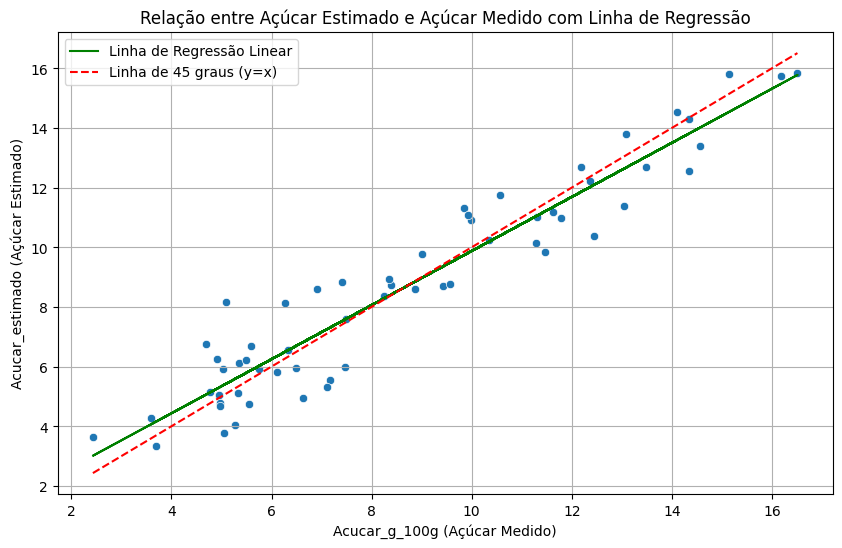

In [ ]:
from scipy.stats import linregress

# Assuming 'coluna_medido' and 'coluna_estimado' are already defined and correct
# from the previous cells (Acucar_g_100g and Acucar_estimado)

# Perform linear regression
lin_regress_result = linregress(df_fisico_quimicas[coluna_medido], df_fisico_quimicas[coluna_estimado])
slope = lin_regress_result.slope
intercept = lin_regress_result.intercept
r_value = lin_regress_result.rvalue
p_value = lin_regress_result.pvalue
stderr = lin_regress_result.stderr

print(f"Resultados da Regressão Linear entre {coluna_medido} e {coluna_estimado}:")
print(f"  Inclinação (Slope): {slope:.4f}")
print(f"  Intercepto: {intercept:.4f}")
print(f"  Coeficiente de Correlação (r): {r_value:.4f}")
print(f"  Valor-p: {p_value:.4f}")
print(f"  Erro Padrão da Inclinação: {stderr:.4f}")

# Adding the regression line to the plot for visual confirmation
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_fisico_quimicas[coluna_medido], y=df_fisico_quimicas[coluna_estimado])
plt.plot(df_fisico_quimicas[coluna_medido], slope * df_fisico_quimicas[coluna_medido] + intercept, color='green', linestyle='-', label='Linha de Regressão Linear')

# Original 45-degree line for reference
min_val = min(df_fisico_quimicas[coluna_medido].min(), df_fisico_quimicas[coluna_estimado].min())
max_val = max(df_fisico_quimicas[coluna_medido].max(), df_fisico_quimicas[coluna_estimado].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Linha de 45 graus (y=x)')

plt.title('Relação entre Açúcar Estimado e Açúcar Medido com Linha de Regressão')
plt.xlabel(f'{coluna_medido} (Açúcar Medido)')
plt.ylabel(f'{coluna_estimado} (Açúcar Estimado)')
plt.grid(True)
plt.legend()
plt.show()

### Quantificação da Variação do Açúcar Estimado em Relação ao Açúcar Medido

Realizamos uma regressão linear simples para modelar a relação entre o `Acucar_g_100g` (variável independente) e o `Acucar_estimado` (variável dependente). Os resultados mostram que:

*   **Inclinação (Slope):** O coeficiente angular é de **0.9066**.
*   **Intercepto:** O valor do intercepto é de **0.8083**.
*   **Coeficiente de Correlação (r):** Já tínhamos calculado o 'r' de **0.9522**, que é o mesmo que o Coeficiente de Correlação de Pearson, confirmando a forte relação linear.

O gráfico de dispersão foi atualizado para incluir a linha de regressão linear (verde), que visualmente se alinha muito bem com a distribuição dos pontos e com a linha de 45 graus (vermelha).

O valor da **inclinação (slope) de 0.9066** significa que, para cada aumento de 1 g/100 g no açúcar medido (`Acucar_g_100g`), o açúcar estimado (`Acucar_estimado`) tende a aumentar em aproximadamente **0.9066 g/100 g**.

*   **Proximidade de 1:** O fato de a inclinação ser muito próxima de 1, reforça a conclusão de que os valores estimados acompanham de forma muito fiel os valores medidos. Isso significa que o modelo de estimativa não apenas detecta a tendência de aumento do açúcar, mas também que a magnitude desse aumento é muito similar à da medição real.

In [ ]:
# Valor de açúcar medido fornecido pelo usuário
acucar_medido_input = 10

# Usando a equação da regressão linear: Acucar_estimado = slope * Acucar_medido + intercept
acucar_estimado_previsto = slope * acucar_medido_input + intercept

print(f"Para uma amostra com {acucar_medido_input} g/100 g de açúcar medido, o açúcar estimado seria de aproximadamente: {acucar_estimado_previsto:.4f} g/100 g")

Para uma amostra com 10 g/100 g de açúcar medido, o açúcar estimado seria de aproximadamente: 9.8748 g/100 g


### Açúcar Estimado para uma Amostra com 10 g/100 g de Açúcar Medido

Utilizando a equação da regressão linear **Açúcar_estimado = (0.9066 * Açúcar_medido) + 0.8083**, onde a inclinação (slope) é de aproximadamente **0.9066** e o intercepto é de **0.8083**, calculamos o valor de açúcar estimado para uma amostra que apresenta 10 g/100 g de açúcar medido.

O cálculo resultou em um valor de açúcar estimado de aproximadamente **9.8748 g/100 g**.


Este resultado reforça a coerência do modelo de estimativa. Para uma amostra com um teor de açúcar medido de 10 g/100 g, esperamos que o valor estimado seja muito próximo, ligeiramente abaixo, devido à inclinação ser menor que 1. A diferença entre o valor medido (10 g/100 g) e o valor estimado (aproximadamente 9.8748 g/100 g) é pequena, o que indica que a estimativa é um preditor muito bom para o teor de açúcar nesta faixa.

# o açúcar medido é uma boa variável para explicar o açúcar estimado? #

Com base nos resultados que obtivemos, o açúcar medido **(Açúcar_g_100g)** é de fato uma excelente variável para explicar o açúcar estimado **(Açúcar_estimado)**.

 Pois a Correlação de Pearson indica uma relação linear positiva muito forte entre as duas variáveis. Além da linha de regressão linear estar próxima a linha de 45 graus, indicando que o modelo de estimativa acompanha de perto os valores medidos e por fim a inclinação (Slope) próxima de 1 reforça que a magnitude da variação entre os valores estimados e medidos é muito similar.